In [1]:
import os
import cv2
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor
from circle_fit import taubinSVD

In [2]:
# instance of extractor
extractor = Extractor()
extractor.load_model()

# 1.extract roi

In [3]:
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    '''
    rotate image with no cut out vertices
    Args:
        img: original image
        scaleFactor: scale of output image
        degreesCCW: angle (degrees)
    Return:
        rotateImg: rotated image
        M: rotate matrix
    '''
    h,w,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(w/2,h/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    new_w,new_h = w*scaleFactor,h*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    new_w,new_h = (abs(np.sin(r)*new_h) + abs(np.cos(r)*new_w),abs(np.sin(r)*new_w) + abs(np.cos(r)*new_h))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((new_w-w)/2,(new_h-h)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(new_w),int(new_h)))
    return rotatedImg,M

In [4]:
def calc_dist(pt1,pt2):
    '''
    Calculate distance of 2 point
    Args:
        pt1: first point
        pt2: second point
    Return:
        dist: distance
    '''
    dist = cv2.norm(pt1-pt2)
    return dist

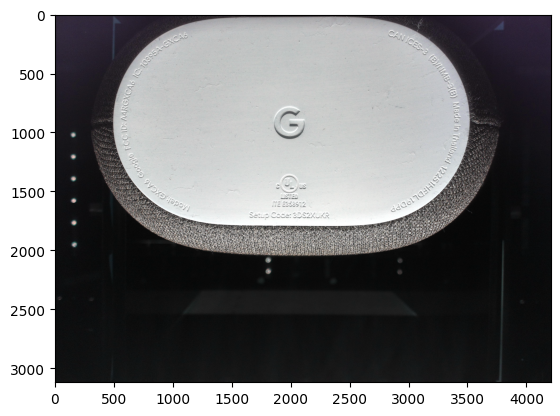

In [5]:
img_org = cv2.imread("snippets/Google Nest Audio.jpg") #"Google Nest Audio.jpg"
img = img_org.copy()
plt.imshow(img)

In [6]:
# extract mask
mask = extractor.get_mask(img)

/home/greystone/locchuong/ocr-exp/pre_post_processing.py:115: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  xmin = np.clip(np.floor(box[:, 0].min()).astype(np.int), 0, w - 1)
/home/greystone/locchuong/ocr-exp/pre_post_processing.py:116: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, c

In [7]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [8]:
# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)

In [9]:
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)

(3104, 4192, 3)


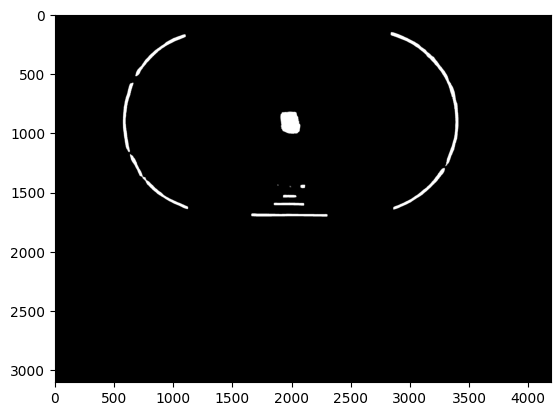

In [10]:
mask3 = cv2.merge([mask.astype("uint8"),mask.astype("uint8"),mask.astype("uint8")])
print(mask3.shape)
plt.imshow(mask3)

8
boxs 8


Text(0.5, 1.0, 'greater then mean rotated rectangle')

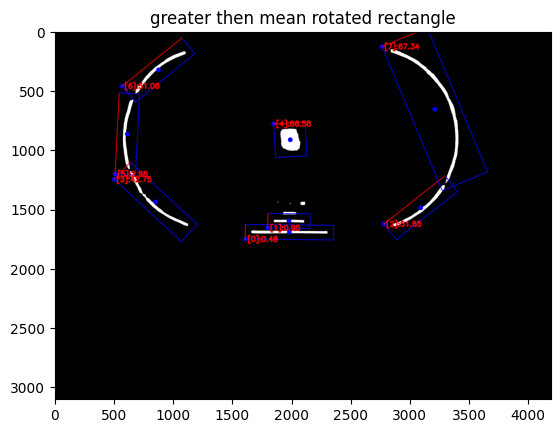

In [11]:
padding = 100
boxs = []
rects = []
angles = [] # degree
img = mask3.copy()
for i,cnt in enumerate(cnts):
    # roated rect (minimum rect)
    rect = cv2.minAreaRect(cnt)
    # angle
    angle = rect[-1]
    angles.append(angle)
    # new rect add padding
    h = int(rect[1][0]+ padding)
    w = int(rect[1][1]+ padding)
    new_rect = (rect[0],(h,w),angle) #h,w
    rects.append(new_rect)
    box = cv2.boxPoints(new_rect)
    box = np.int0(box)
    boxs.append(box)
    # draw
    cv2.drawContours(img,[box],0,(0,0,255),6) # min rect
    cv2.circle(img,(int(rect[0][0]),int(rect[0][1])),20,(0,0,255),-1)# top point
    cv2.circle(img,box[0],20,(0,0,255),-1)# top point
    cv2.line(img,box[0],box[1],(255,0,0),6)# top line
    cv2.putText(img,f"[{i}]:{round(angle,2)}",box[0]+np.array([20,20]),cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle

print(len(boxs))
print(f"boxs {len(boxs)}")
plt.imshow(img)
plt.title("greater then mean rotated rectangle")

In [12]:
rois = []
masks = []

for i,t in enumerate(angles):
    # original input
    img = img_org.copy()
    img_mask = mask3.copy()
    rect = rects[i]
    box = boxs[i] # 4 pts form of rect
    rebox = box.reshape(-1,1,2)
    #rotate
    img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
    img_mask,_ = rotateAndScale(img_mask, scaleFactor = 2.0, degreesCCW = t)
    rebox = cv2.transform(rebox, M) # what you need
    # find new top left,bottom right
    dist = []
    for pt in rebox.reshape(-1,2):
        d = calc_dist(np.array([0,0]),pt)
        dist.append(d)
    top_left = rebox.reshape(-1,2)[np.argmin(dist)]
    bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
    w,h = bottom_right - top_left
    x,y = top_left
    out = img[y:y+h,x:x+w]
    out_m = img_mask[y:y+h,x:x+w]
    rois.append(out)
    masks.append(out_m)

In [13]:
for i,roi in enumerate(rois):
    h,w,c = roi.shape
    if h > w:
        roi = cv2.rotate(roi,cv2.ROTATE_90_CLOCKWISE)
        rois[i]=roi

In [14]:
for i,mask in enumerate(masks):
    h,w,c = mask.shape
    if h > w:
        mask = cv2.rotate(mask,cv2.ROTATE_90_CLOCKWISE)
        masks[i]=mask

<Figure size 640x480 with 0 Axes>

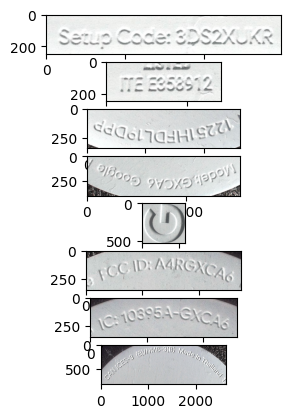

In [15]:
plt.figure()

fig,ax = plt.subplots(len(rois),1)
for i in range(len(rois)):
    ax[i].imshow(rois[i])

<Figure size 640x480 with 0 Axes>

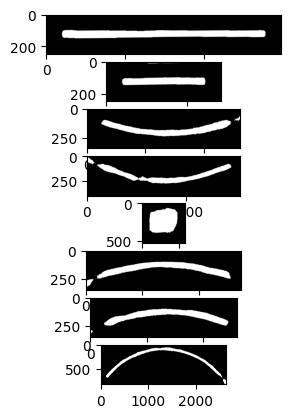

In [16]:
plt.figure()

fig,ax = plt.subplots(len(masks),1)
for i in range(len(masks)):
    ax[i].imshow(masks[i])

# 2.fit-in circle

(395, 1542)


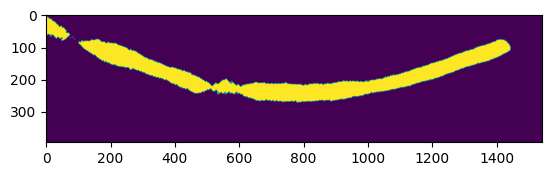

In [40]:
idx=3
mask = masks[idx]
mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
h,w = mask.shape
print(mask.shape)
plt.imshow(mask)

In [41]:
curve = []
for i in range(w):
    v_line = mask[:,i:i+1]
    pos = cv2.findNonZero(v_line)
    if pos is not None:
        curve.append((pos[0][0][1],i))

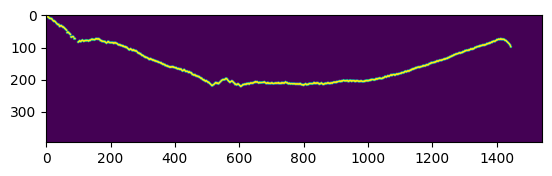

In [42]:
blank = np.zeros_like(mask)
for point in curve:
    cv2.circle(blank,(point[1], point[0]), 3, (255,255,255), -1)
plt.imshow(blank)

In [43]:
xc, yc, r, sigma = taubinSVD(curve)
r = int(r)
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

xc=-1291, yc=774, r=1507, sigma=8.533820865340683


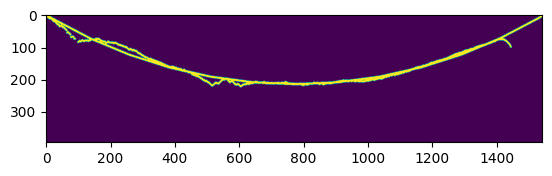

In [44]:
cv2.circle(blank, (int(yc),int(xc)), int(r), (255), 6)
plt.imshow(blank)

In [45]:
if xc<0:
    mask = cv2.rotate(mask,cv2.ROTATE_180)
    roi = cv2.rotate(roi,cv2.ROTATE_180)
    x = int(r - w/2)
    y = 2*r-h
    x2 = x+w
    y2 = 2*r
else:
    x = int(r - w/2)
    y = 0
    x2 = x+w
    y2 = h

# 3.wrap roi

(3014, 3014, 3)


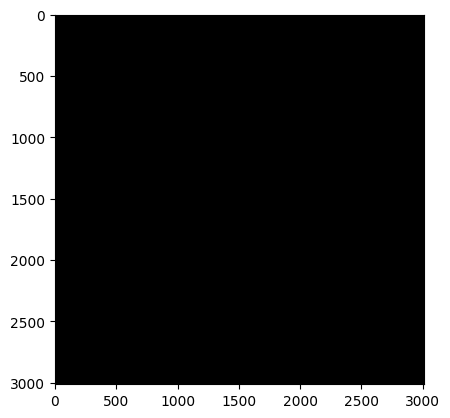

In [46]:
blank = np.zeros((r*2,r*2,3))
blank_mask = np.zeros((r*2,r*2,3))
blank = blank.astype(np.uint8)
print(blank.shape)
plt.imshow(blank)

In [47]:
blank[y:y2,x:x2].shape

(395, 1542, 3)

Text(0.5, 1.0, 'color')

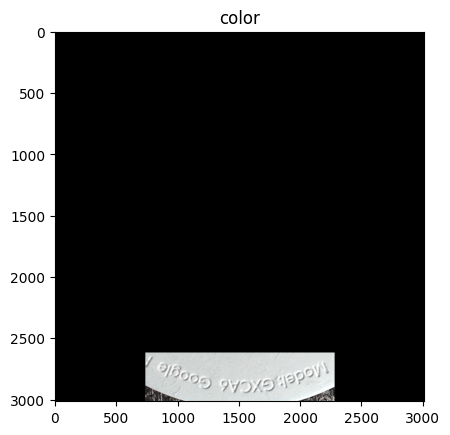

In [48]:
blank[y:y2,x:x2]= rois[idx]
plt.imshow(blank)
plt.title("color")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'mask')

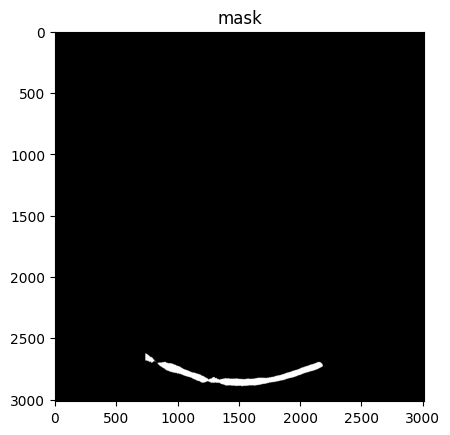

In [49]:
blank_mask[y:y2,x:x2]= masks[idx]
plt.imshow(blank_mask)
plt.title("mask")

Text(0.5, 1.0, 'color')

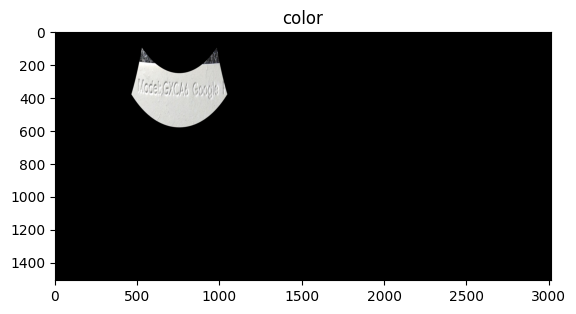

In [50]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_img = cv2.warpPolar(blank,(r,r*2),(r,r),r+300,flags) # w,h
out = polar_img.transpose(1,0,2)[::-1]
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.title('color')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'mask')

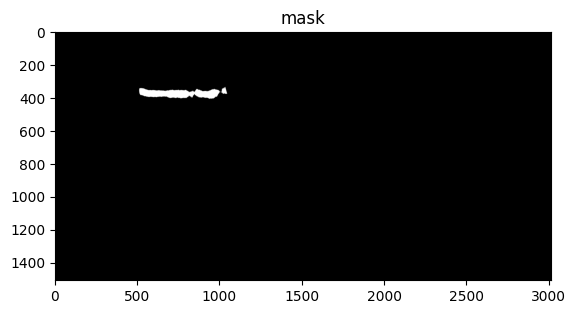

In [51]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_mask = cv2.warpPolar(blank_mask,(r,r*2),(r,r),r+300,flags) # w,h
out_m = polar_mask.transpose(1,0,2)[::-1]
plt.imshow(out_m)
plt.title('mask')

In [52]:
# convert to np.uint8
out_m = out_m.astype(np.uint8)
print(f"max value: {out_m.max()}")
print(f"min value: {out_m.min()}")

max value: 255
min value: 0


In [53]:
gray = cv2.cvtColor(out_m, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, 0)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(len(contours))

108


In [54]:
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)
    
cnt_max = contours[np.argmax(areas)]

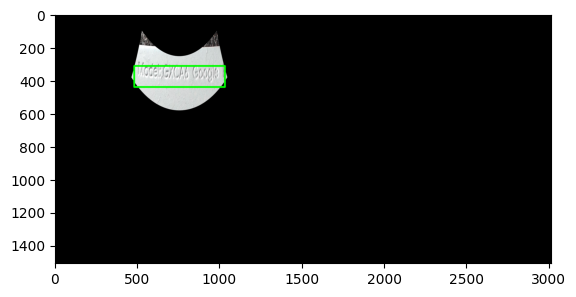

In [55]:
padding = 30
img = out.copy()
xr,yr,w,h = cv2.boundingRect(cnt_max)
cv2.rectangle(img,(xr-padding,yr-padding),(xr+w+padding,yr+h+padding),(0,255,0),10)
plt.imshow(img)

In [56]:
height,width,c=out.shape

In [57]:
y_list = []
for i in range(height):
    h_line = out[i:i+1,:]
    if np.sum(h_line) != 0:
        y_list.append(i)

y0=y_list[0]
y1=y_list[-1]
print(f"y0={y0},y1={y1}")

y0=95,y1=579


In [58]:
x_list = []
for i in range(width):
    v_line = out[:,i:i+1]
    if np.sum(v_line) != 0:
        x_list.append(i)
x0=x_list[0]
x1=x_list[-1]
print(f"x0={x0},x1={x1}")

x0=463,x1=1045


True

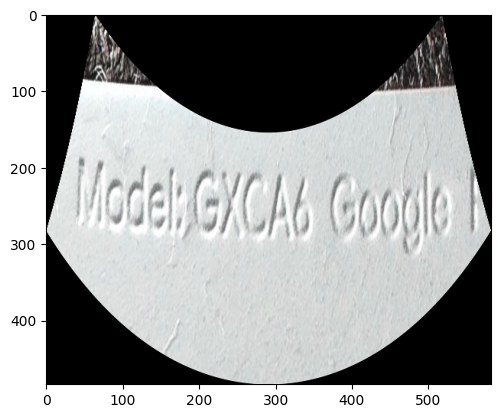

In [59]:
out1 = out[y0:y1,x0:x1]
plt.imshow(out1)
cv2.imwrite("out.jpg",out1)

In [60]:
x0=xr-padding
y0=yr-padding
x1=xr+w+padding
y1=yr+h+padding
print(f"x0={x0},y0={y0},x1={x1},y1={y1}")

x0=480,y0=309,x1=1030,y1=437


(1507, 3014, 3)


True

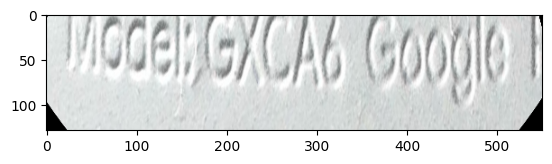

In [61]:
out2 = out[y0:y1,x0:x1]
print(out.shape)
plt.imshow(out2)
cv2.imwrite("out.jpg",out2)

In [39]:
lab= cv2.cvtColor(out2, cv2.COLOR_BGR2LAB)
l_channel, a, b = cv2.split(lab)

# Applying CLAHE to L-channel
# feel free to try different values for the limit and grid size:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(l_channel)

# merge the CLAHE enhanced L-channel with the a and b channel
limg = cv2.merge((cl,a,b))

# Converting image from LAB Color model to BGR color spcae
out2 = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

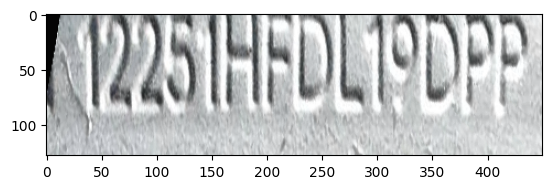

In [263]:
plt.imshow(out2)

# 4.Text recognition

In [50]:
extractor.run(list(range(1)),[out2])

Extractor executing..
Processing image: 0


[{'name': 0, 'results': []}]

In [51]:
import keras_ocr

2023-01-05 09:10:16.277706: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-01-05 09:10:18.078308: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/greystone/locchuong/ocr-exp/env/lib/python3.8/site-packages/cv2/../../lib64:/usr/local/cuda-11.4/lib64
2023-01-05 09:10:18.078560: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/greystone/locch

In [52]:
pipeline = keras_ocr.pipeline.Pipeline()

Looking for /home/greystone/.keras-ocr/craft_mlt_25k.h5


2023-01-05 09:10:22.833567: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2023-01-05 09:10:22.833662: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (greystone-B560M-GAMING-HD): /proc/driver/nvidia/version does not exist
2023-01-05 09:10:22.836748: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Looking for /home/greystone/.keras-ocr/crnn_kurapan.h5


2023-01-05 09:10:25.077909: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 61422592 exceeds 10% of free system memory.
2023-01-05 09:10:25.201863: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 61422592 exceeds 10% of free system memory.
2023-01-05 09:10:25.360919: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 61422592 exceeds 10% of free system memory.
2023-01-05 09:10:25.398851: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 61422592 exceeds 10% of free system memory.


1/1 [==============================] - 1s 1s/step


2023-01-05 09:10:25.797971: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 46066944 exceeds 10% of free system memory.


1/1 [==============================] - 1s 1s/step


<AxesSubplot: >

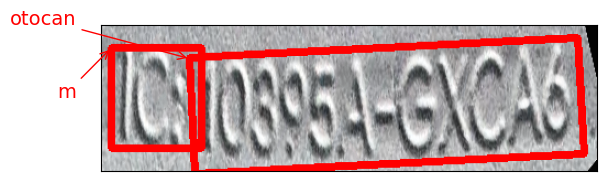

In [53]:
imgs = [out2]
preds = pipeline.recognize(imgs)
# draw prediction
fig,ax = plt.subplots()
# plt.figure(figsize=(10,10))
keras_ocr.tools.drawAnnotations(image=imgs[0],predictions=preds[0],ax=ax)

# references

[opencv-text-recognition](https://docs.opencv.org/4.x/d4/d43/tutorial_dnn_text_spotting.html)


[deep-text-recognition-benchmark](https://github.com/clovaai/deep-text-recognition-benchmark)


[AdelaiDet](https://github.com/aim-uofa/AdelaiDet)


[adaptive-bezier-curve-network](https://www.kaggle.com/code/ipythonx/scene-text-spotting-adaptive-bezier-curve-network)